<a href="https://colab.research.google.com/github/Raulfb04/Simulaci-n-1/blob/main/TIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: Simulación del peso total de tinas en un camión

La empresa TIBASA fabrica tinas de baño y cuenta con un camión especial para transportar diariamente 5 tinas terminadas.

El peso de cada tina sigue una distribución triangular, de acuerdo con la gráfica proporcionada. A partir de la imagen se identifica que:

- Peso mínimo: $(a=190)$ kg
- Peso más probable o moda: $(c=210)$ kg
- Peso máximo: $(b=230)$ kg

La capacidad máxima del camión es de 1 tonelada, es decir:

$1000 \text{kg}$

El objetivo es estimar, mediante simulación, la probabilidad de que el peso total de las 5 tinas exceda la capacidad del camión:

$P(X_1+X_2+X_3+X_4+X_5>1000)$

In [2]:
# Importamos las librerías necesarias

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Paso 1. Definición de la distribución triangular

Sea $(X)$ la variable aleatoria que representa el peso de una tina.

De acuerdo con la gráfica, $(X)$ tiene una distribución triangular con parámetros:

$a=190,\quad c=210,\quad b=230$

Como la moda $(c=210)$ está justo a la mitad entre 190 y 230, la distribución triangular es simétrica.

La función de densidad es:

$f(x)=
\begin{cases}
\dfrac{x-190}{400}, & 190 \le x \le 210,\\[6pt]
\dfrac{230-x}{400}, & 210 < x \le 230,\\[6pt]
0, & \text{en otro caso.}
\end{cases}$

## Paso 2. Función de distribución acumulada

Para aplicar el método de la transformada inversa, primero necesitamos obtener la función de distribución acumulada \(F(x)\).

Para $(190\le x\le 210)$:

$F(x)=\int_{190}^{x}\frac{t-190}{400}\,dt$

$F(x)=\frac{(x-190)^2}{800}$

Para $(210<x\le 230)$:

$F(x)=1-\frac{(230-x)^2}{800}$

Por lo tanto:

$F(x)=
\begin{cases}
0, & x<190,\\[6pt]
\dfrac{(x-190)^2}{800}, & 190\le x\le 210,\\[6pt]
1-\dfrac{(230-x)^2}{800}, & 210<x\le 230,\\[6pt]
1, & x>230.
\end{cases}$

## Paso 3. Transformada inversa

Sea $(R\sim U(0,1))$. Igualamos:

$F(x)=R$

Para la primera parte:

$R=\frac{(x-190)^2}{800}$

$x=190+\sqrt{800R}$

Para la segunda parte:

$R=1-\frac{(230-x)^2}{800}$


$x=230-\sqrt{800(1-R)}$

Como $(F(210)=0.5)$, la transformada inversa queda:

$X=
\begin{cases}
190+\sqrt{800R}, & 0\le R\le 0.5,\\[6pt]
230-\sqrt{800(1-R)}, & 0.5<R\le 1.
\end{cases}$

In [3]:
# Definimos una función para generar el peso de una tina
# usando el método de la transformada inversa.

def generar_peso_tina():
    R = np.random.random()  # número aleatorio uniforme entre 0 y 1

    if R <= 0.5:
        X = 190 + np.sqrt(800 * R)
    else:
        X = 230 - np.sqrt(800 * (1 - R))

    return X

In [4]:
# Probamos la función generando algunos pesos de tinas

for i in range(10):
    print(generar_peso_tina())

210.2434645799523
214.24454512907943
203.71895343726067
209.2657322205093
200.81237611267696
206.92585818369355
210.2871374013891
224.58602588551858
192.16311828277173
214.20381779026837


## Paso 4. Definición de la variable aleatoria del problema

Sea $X_1, X_2, X_3, X_4, X_5$ el peso de las 5 tinas transportadas por el camión.

Cada una sigue una distribución triangular:

$X_i \sim Triangular(190,210,230)$

La variable de interés es:

$$
S = X_1 + X_2 + X_3 + X_4 + X_5
$$

Queremos estimar mediante simulación la probabilidad:

$$
P(S > 1000)
$$

es decir, la probabilidad de que el peso total exceda la capacidad del camión.

In [5]:
# Función que simula el peso total de las 5 tinas en un viaje

def simular_viaje():

    suma = 0

    for i in range(5):
        suma += generar_peso_tina()

    return suma

In [6]:
# Probamos algunos viajes simulados

for i in range(10):
    print(simular_viaje())

1036.8762504903543
1077.3988620448495
1049.988484898298
1056.9301054875373
1062.9741673742926
1062.915076803203
1069.5132274226253
1054.8367341371988
1061.8746218238796
1001.6376675802146


## Paso 5. Simulación Monte Carlo

Para estimar la probabilidad $P(S > 1000)$ se utiliza el método de Monte Carlo.

El procedimiento consiste en:

1. Simular el peso de 5 tinas
2. Calcular la suma total $S$
3. Verificar si $S > 1000$
4. Repetir el proceso muchas veces
5. Calcular la frecuencia relativa del evento

In [7]:
# Número de simulaciones

N = 100000

contador = 0


for i in range(N):

    S = simular_viaje()

    if S > 1000:
        contador += 1


probabilidad = contador / N

probabilidad

0.9974

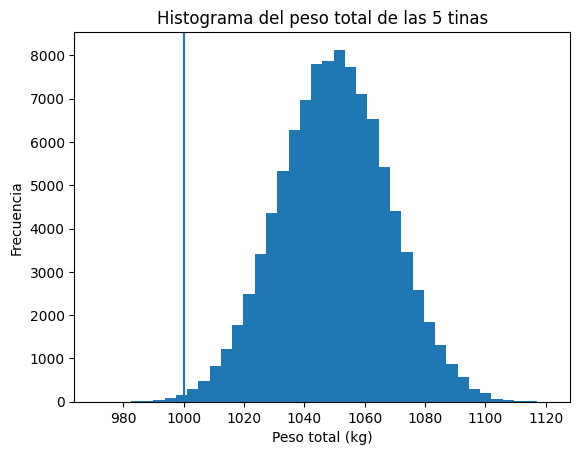

In [8]:
# Generamos valores de S para construir el histograma

valores_S = []

for i in range(N):
    valores_S.append(simular_viaje())


plt.hist(valores_S, bins=40)
plt.axvline(1000)
plt.title("Histograma del peso total de las 5 tinas")
plt.xlabel("Peso total (kg)")
plt.ylabel("Frecuencia")
plt.show()

## Paso 6. Interpretación del resultado

Después de realizar la simulación Monte Carlo con $100000$ repeticiones, se obtiene una estimación de la probabilidad de que el peso total de las 5 tinas exceda los 1000 kg.

Esta probabilidad representa la frecuencia relativa con la que el camión supera su capacidad máxima de carga.